# Ejercicio 3 - Impacto de la Tasa de Mutacion

Este notebook implementa el Ejercicio 3 de la guia de laboratorio, continuando directamente sobre el Ejercicio 1 (`max._cubica.ipynb`). El objetivo es ejecutar el mismo algoritmo genetico que maximiza

$$f(x) = x^3 - 4x^2 + 5x$$

tres veces, cambiando **unicamente** la probabilidad de mutacion `pm` (0.01, 0.1 y 0.5), dejando fijos todos los demas parametros (poblacion, generaciones, `pc`, metodo de seleccion, elitismo y rango de busqueda). Con esto se busca comparar las curvas de convergencia y analizar como la tasa de mutacion afecta la velocidad de convergencia y la diversidad de la poblacion.

## Alcance de esta entrega

- Reutilizar la clase `AlgoritmoGenetico` y los parametros base definidos en el Ejercicio 1
- Definir una funcion parametrizable `ejecutar_ag(pm)` que corra el AG completo y devuelva su historial
- Ejecutar tres corridas (pm = 0.01, 0.1, 0.5) con la misma semilla para aislar el efecto de `pm`
- Graficar la convergencia (mejor fitness) y la diversidad poblacional (desviacion estandar del fitness) por generacion, para las tres tasas de mutacion
- Generar una tabla resumen comparativa y un analisis escrito de los resultados

**Rama de trabajo:** `tasa_mutacion` (a partir de `main`, complementando la rama del Ejercicio 1)

Ejercicio 3 elaborado por Nicolas Ballesteros

## 1. Configuracion e imports

Se reutilizan las mismas librerias del Ejercicio 1: `numpy`, `pandas` y `matplotlib` para el manejo numerico, tabular y la visualizacion. `ipywidgets` se deja disponible de forma opcional por si se quiere explorar `pm` de manera interactiva mas adelante.

In [1]:
import copy
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import ipywidgets as widgets
    from IPython.display import display
except ImportError:
    widgets = None
    display = None

random.seed(42)
np.random.seed(42)

plt.style.use("seaborn-v0_8-whitegrid")

print("Imports cargados correctamente.")

"""librerias similares al ejercicio 1"""

Imports cargados correctamente.


'librerias similares al ejercicio 1'

## 2. Parametros base (similares a Ejercicio 1)

Estos son exactamente los mismos parametros y funciones (`fitness_cubica`, `decode_binary_to_real`) usados en el Ejercicio 1. La unica variable que cambiara entre corridas es `pm`, que se dejara como parametro de la funcion `ejecutar_ag` en la siguiente seccion.

In [2]:
x_min = 0.0
x_max = 1.55
n_bits = 16
population_size = 40
num_generations = 60
pc = 0.85
selection_method = "roulette"
elitism = True


def fitness_cubica(x: float) -> float:
    """calcula la aptitud de la funcion objetivo del ejercicio 1"""
    return x**3 - 4 * x**2 + 5 * x


def decode_binary_to_real(chromosome: list[int], lower_bound: float = x_min, upper_bound: float = x_max) -> float:
    """decodifica un cromosoma binario a un valor real dentro del intervalo definido"""
    integer_value = int("".join(map(str, chromosome)), 2)
    max_integer = (2 ** len(chromosome)) - 1
    return lower_bound + (integer_value / max_integer) * (upper_bound - lower_bound)

## 3. Clase `AlgoritmoGenetico`

Se reutiliza tal cual la clase del Ejercicio 1. Como novedad para este ejercicio, cada fila del historial de generaciones ahora tambien registra `std_fitness` (la desviacion estandar del fitness de toda la poblacion en esa generacion), que se usara como una medida de **diversidad poblacional** para comparar el efecto de `pm`.

In [3]:
class AlgoritmoGenetico:
    """implementacion modular de un algoritmo genetico binario para maximizacion"""
    """Inviocado del ejercicio 1 """
    def __init__(
        self,
        population_size: int,
        chromosome_length: int,
        pc: float,
        pm: float,
        fitness_func,
        decode_func,
        selection_method: str = "roulette",
        elitism: bool = True,
        tournament_size: int = 3,
    ) -> None:
        if not (0 <= pc <= 1 and 0 <= pm <= 1):
            raise ValueError("pc y pm deben estar entre 0 y 1.")
        if population_size <= 0 or chromosome_length <= 0:
            raise ValueError("population_size y chromosome_length deben ser positivos.")
        if selection_method not in {"roulette", "tournament"}:
            raise ValueError("selection_method debe ser 'roulette' o 'tournament'.")

        self.population_size = population_size
        self.chromosome_length = chromosome_length
        self.pc = pc
        self.pm = pm
        self.fitness_func = fitness_func
        self.decode_func = decode_func
        self.selection_method = selection_method
        self.elitism = elitism
        self.tournament_size = tournament_size

        self.population: list[list[int]] = []
        self.max_fitness_history: list[float] = []
        self.avg_fitness_history: list[float] = []
        self.best_individual_genotype: list[int] = []
        self.best_individual_fitness: float = -float("inf")
        self.best_individual_phenotype: float | None = None
        self.best_generation: int | None = None
        self.last_population_snapshots: list[list[list[int]]] = []
        self.last_fitness_snapshots: list[list[float]] = []
        self.last_phenotype_snapshots: list[list[float]] = []
        self.last_history_frame: pd.DataFrame = pd.DataFrame()

    def _initialize_population(self) -> None:
        self.population = [
            [random.randint(0, 1) for _ in range(self.chromosome_length)]
            for _ in range(self.population_size)
        ]

    def _calculate_all_fitness(self, population: list[list[int]]) -> tuple[list[float], list[float]]:
        fitness_values: list[float] = []
        phenotypes: list[float] = []
        for chromosome in population:
            phenotype = self.decode_func(chromosome)
            fitness_value = self.fitness_func(phenotype)
            phenotypes.append(phenotype)
            fitness_values.append(fitness_value)
        return fitness_values, phenotypes

    def _select_proportional(self, population: list[list[int]], fitness_values: list[float]) -> list[list[int]]:
        min_fitness = min(fitness_values)
        adjusted_fitness = [f - min_fitness + 1e-6 for f in fitness_values] if min_fitness < 0 else fitness_values
        total_fitness = sum(adjusted_fitness)

        if total_fitness == 0:
            return random.choices(population, k=self.population_size)

        return random.choices(population, weights=adjusted_fitness, k=self.population_size)

    def _select_tournament(self, population: list[list[int]], fitness_values: list[float]) -> list[list[int]]:
        selected_population: list[list[int]] = []
        for _ in range(self.population_size):
            contestants = random.sample(range(self.population_size), self.tournament_size)
            winner_index = max(contestants, key=lambda index: fitness_values[index])
            selected_population.append(copy.deepcopy(population[winner_index]))
        return selected_population

    def _crossover_one_point(self, parent1: list[int], parent2: list[int]) -> tuple[list[int], list[int]]:
        if random.random() < self.pc:
            crossover_point = random.randint(1, self.chromosome_length - 1)
            child1 = parent1[:crossover_point] + parent2[crossover_point:]
            child2 = parent2[:crossover_point] + parent1[crossover_point:]
            return child1, child2
        return copy.deepcopy(parent1), copy.deepcopy(parent2)

    def _mutate_flip_bit(self, chromosome: list[int]) -> list[int]:
        mutated = copy.deepcopy(chromosome)
        for index in range(self.chromosome_length):
            if random.random() < self.pm:
                mutated[index] = 1 - mutated[index]
        return mutated

    def _apply_elitism(self, new_population: list[list[int]]) -> list[list[int]]:
        if not self.elitism or not self.best_individual_genotype:
            return new_population

        new_fitness_values, _ = self._calculate_all_fitness(new_population)
        worst_index = int(np.argmin(new_fitness_values))
        new_population[worst_index] = copy.deepcopy(self.best_individual_genotype)
        return new_population

    def run(self, num_generations: int) -> tuple[list[int], float, list[dict]]:
        self._initialize_population()
        self.max_fitness_history = []
        self.avg_fitness_history = []
        self.last_population_snapshots = []
        self.last_fitness_snapshots = []
        self.last_phenotype_snapshots = []
        history_rows: list[dict] = []

        for generation in range(num_generations):
            fitness_values, phenotypes = self._calculate_all_fitness(self.population)
            best_index = int(np.argmax(fitness_values))
            best_fitness = float(fitness_values[best_index])
            best_genotype = copy.deepcopy(self.population[best_index])
            best_phenotype = float(phenotypes[best_index])

            if best_fitness > self.best_individual_fitness:
                self.best_individual_fitness = best_fitness
                self.best_individual_genotype = best_genotype
                self.best_individual_phenotype = best_phenotype
                self.best_generation = generation

            average_fitness = float(np.mean(fitness_values))
            std_fitness = float(np.std(fitness_values))  # medida de diversidad poblacional
            self.max_fitness_history.append(best_fitness)
            self.avg_fitness_history.append(average_fitness)
            self.last_population_snapshots.append(copy.deepcopy(self.population))
            self.last_fitness_snapshots.append(fitness_values.copy())
            self.last_phenotype_snapshots.append(phenotypes.copy())

            history_rows.append(
                {
                    "generacion": generation,
                    "mejor_fitness": best_fitness,
                    "fitness_promedio": average_fitness,
                    "std_fitness": std_fitness,
                    "mejor_x": best_phenotype,
                }
            )

            selected_population = (
                self._select_proportional(self.population, fitness_values)
                if self.selection_method == "roulette"
                else self._select_tournament(self.population, fitness_values)
            )

            new_population: list[list[int]] = []
            for index in range(0, self.population_size, 2):
                parent1 = selected_population[index]
                parent2 = selected_population[(index + 1) % self.population_size]
                child1, child2 = self._crossover_one_point(parent1, parent2)
                new_population.append(self._mutate_flip_bit(child1))
                if len(new_population) < self.population_size:
                    new_population.append(self._mutate_flip_bit(child2))

            self.population = self._apply_elitism(new_population[: self.population_size])

        self.last_history_frame = pd.DataFrame(history_rows)
        return self.best_individual_genotype, self.best_individual_fitness, history_rows

## 4. Funcion parametrizable `ejecutar_ag(pm)`

Se envuelve la logica del Ejercicio 1 en una funcion que recibe `pm` como argumento y devuelve tanto la instancia del AG ya ejecutada como su historial de convergencia por generacion, mas un pequeno resumen (mejor `x`, mejor fitness, generacion en la que se alcanzo y numero de individuos unicos en la poblacion final, como *proxy* de diversidad). Se fija una semilla (`seed=42`) igual para las tres corridas, de manera que la unica diferencia entre ellas sea `pm`.

In [4]:
def ejecutar_ag(pm: float, seed: int = 42) -> dict:
    """ejecuta el AG del ejercicio 1 con un valor de pm dado, dejando fijos los demas parametros"""
    random.seed(seed)
    np.random.seed(seed)

    ag_local = AlgoritmoGenetico(
        population_size=population_size,
        chromosome_length=n_bits,
        pc=pc,
        pm=pm,
        fitness_func=fitness_cubica,
        decode_func=decode_binary_to_real,
        selection_method=selection_method,
        elitism=elitism,
    )
    best_genotype, best_fitness, history_rows = ag_local.run(num_generations=num_generations)

    for row in history_rows:
        row["pm"] = pm

    individuos_unicos_final = len({tuple(cromosoma) for cromosoma in ag_local.population})
    best_x = decode_binary_to_real(best_genotype)

    resumen = {
        "pm": pm,
        "mejor_x": best_x,
        "mejor_fitness": best_fitness,
        "generacion_mejor": ag_local.best_generation,
        "individuos_unicos_final": individuos_unicos_final,
    }
    return {"ag": ag_local, "history_rows": history_rows, "resumen": resumen}

## 5. Loop comparativo: pm = 0.01, 0.1, 0.5

Se ejecuta `ejecutar_ag` tres veces, una por cada tasa de mutacion pedida en el enunciado, y se consolidan todos los historiales en un unico `DataFrame` (`df_resultados`) con una columna `pm` que permite diferenciar cada corrida.

In [5]:
valores_pm = [0.01, 0.1, 0.5]
resultados_por_pm = {}
filas_historial = []
filas_resumen = []
"""valor de pm en el que se ejecuta el algoritmo genetico """
for pm_valor in valores_pm:
    resultado = ejecutar_ag(pm=pm_valor, seed=42)
    resultados_por_pm[pm_valor] = resultado
    filas_historial.extend(resultado["history_rows"])
    filas_resumen.append(resultado["resumen"])
    print(
        f"[AG] pm={pm_valor} -> mejor_fitness={resultado['resumen']['mejor_fitness']:.6f}, "
        f"mejor_x={resultado['resumen']['mejor_x']:.6f}, "
        f"generacion={resultado['resumen']['generacion_mejor']}, "
        f"individuos_unicos_final={resultado['resumen']['individuos_unicos_final']}"
    )

df_resultados = pd.DataFrame(filas_historial)
df_resumen = pd.DataFrame(filas_resumen)

df_resultados.head()

[AG] pm=0.01 -> mejor_fitness=2.000000, mejor_x=0.999961, generacion=29, individuos_unicos_final=33
[AG] pm=0.1 -> mejor_fitness=2.000000, mejor_x=1.000008, generacion=17, individuos_unicos_final=38
[AG] pm=0.5 -> mejor_fitness=2.000000, mejor_x=0.999866, generacion=35, individuos_unicos_final=40


,generacion,mejor_fitness,fitness_promedio,std_fitness,mejor_x,pm
0,0,1.999803,1.654501,0.430399,1.014152,0.01
1,1,1.999907,1.829759,0.194098,1.009682,0.01
2,2,1.999907,1.866589,0.139148,1.009682,0.01
3,3,1.999907,1.885515,0.102311,1.009682,0.01
4,4,1.999992,1.896002,0.103609,1.002870,0.01


## 6. Grafica comparativa: convergencia y diversidad poblacional

Se generan dos paneles:

- **Izquierda:** evolucion del mejor fitness por generacion para cada `pm`, junto con una linea de referencia en el optimo teorico de la funcion en el intervalo (`f(1) = 2`)
- **Derecha:** evolucion de la desviacion estandar del fitness de toda la poblacion por generacion (una medida directa de diversidad poblacional), para las mismas tres tasas de mutacion

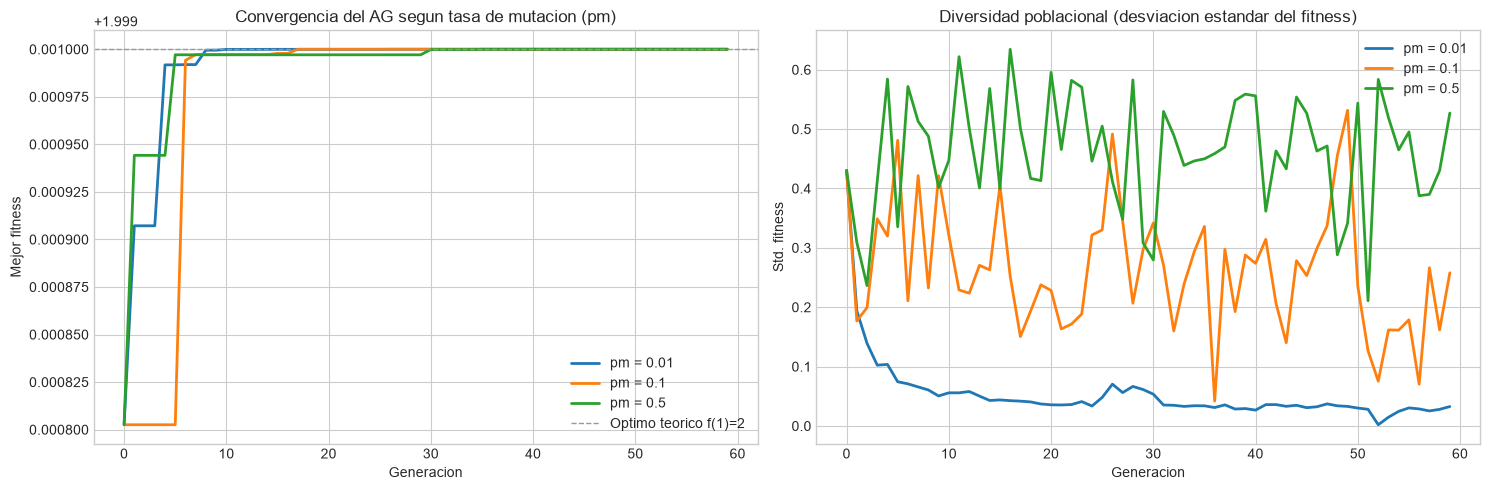

In [6]:
colores = {0.01: "#1f77b4", 0.1: "#ff7f0e", 0.5: "#2ca02c"}
"""grafica de convergencia y diversidad poblacional segun la tasa de mutacion"""
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for pm_valor in valores_pm:
    subset = df_resultados[df_resultados["pm"] == pm_valor]
    axes[0].plot(subset["generacion"], subset["mejor_fitness"], color=colores[pm_valor],
                 linewidth=2, label=f"pm = {pm_valor}")
axes[0].axhline(2.0, color="#999999", linestyle="--", linewidth=1, label="Optimo teorico f(1)=2")
axes[0].set_title("Convergencia del AG segun tasa de mutacion (pm)")
axes[0].set_xlabel("Generacion")
axes[0].set_ylabel("Mejor fitness")
axes[0].legend()
axes[0].grid(True)
"""valores de pm en el que se ejecuta el algoritmo genetico """
for pm_valor in valores_pm:
    subset = df_resultados[df_resultados["pm"] == pm_valor]
    axes[1].plot(subset["generacion"], subset["std_fitness"], color=colores[pm_valor],
                 linewidth=2, label=f"pm = {pm_valor}")
axes[1].set_title("Diversidad poblacional (desviacion estandar del fitness)")
axes[1].set_xlabel("Generacion")
axes[1].set_ylabel("Std. fitness")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 7. Tabla resumen por tasa de mutacion

Se calcula, para cada `pm`, el mejor fitness y `x` encontrados, la generacion en la que se alcanzo el mejor global, el fitness promedio de toda la ejecucion, la diversidad promedio y final (`std_fitness`), y el numero de individuos unicos en la poblacion final (segundo *proxy* de diversidad)

In [7]:
"""resumen de resultados finales por cada valor de pm, incluyendo el promedio y desviacion estandar del fitness promedio y desviacion estandar del fitness final"""
extra = (
    df_resultados.groupby("pm")
    .agg(
        fitness_promedio_medio=("fitness_promedio", "mean"),
        std_fitness_medio=("std_fitness", "mean"),
        std_fitness_final=("std_fitness", "last"),
    )
    .reset_index()
)
"""definicion de un dataframe que contiene el resumen de resultados finales por cada valor de pm, incluyendo el promedio y desviacion estandar del fitness promedio y desviacion estandar del fitness final"""
df_resumen_full = df_resumen.merge(extra, on="pm")
df_resumen_full = df_resumen_full[[
    "pm", "mejor_x", "mejor_fitness", "generacion_mejor",
    "fitness_promedio_medio", "std_fitness_medio", "std_fitness_final",
    "individuos_unicos_final",
]].round(4)

df_resumen_full

,pm,mejor_x,mejor_fitness,generacion_mejor,fitness_promedio_medio,std_fitness_medio,std_fitness_final,individuos_unicos_final
0,0.01,1.0000,2.0,29,1.9529,0.0528,0.0326,33
1,0.10,1.0000,2.0,17,1.8399,0.2630,0.2579,38
2,0.50,0.9999,2.0,35,1.6541,0.4613,0.5269,40


## 8. Analisis de resultados

Con la configuracion base del Ejercicio 1 (poblacion de 40, 60 generaciones, `pc = 0.85`, elitismo activo, rango `[0.0, 1.55]`, la misma semilla en las tres corridas), se observa:

- **Las tres tasas de mutacion (0.01, 0.1 y 0.5) llegan al mismo optimo global** (`x ≈ 1`, `f(x) = 2`). Esto tiene sentido porque el elitismo garantiza que el mejor individuo nunca se pierde y el espacio de busqueda es pequeno y con un unico maximo local claro dentro del rango definido; en un problema mas complejo (mas variables, mas optimos locales) es mas probable ver diferencias en la *calidad* final del optimo, no solo en la velocidad.
- **La generacion en la que se encuentra el mejor individuo no crece de forma monotona con `pm`** en esta ejecucion: `pm=0.1` lo encuentra en la generacion 17, `pm=0.01` en la 29 y `pm=0.5` en la 35. Esto sugiere que una mutacion moderada (0.1) ayuda a explorar rapido sin destruir demasiado buen material genetico, mientras que una mutacion muy alta (0.5) introduce tanto ruido que retrasa un poco la convergencia hacia el optimo exacto, aunque igual lo termina alcanzando gracias al elitismo.
- **La diversidad poblacional (std. del fitness) es donde `pm` marca la diferencia mas clara y consistente:** el promedio de `std_fitness` a lo largo de toda la ejecucion sube de 0.053 (`pm=0.01`) a 0.263 (`pm=0.1`) y a 0.461 (`pm=0.5`). Es decir, entre mas alta la tasa de mutacion, mas heterogenea se mantiene la poblacion generacion tras generacion, en vez de colapsar rapidamente alrededor del mejor individuo.
- **El fitness promedio de la poblacion (no solo el mejor individuo) confirma el mismo patron en sentido contrario:** el promedio general baja de 1.953 (`pm=0.01`) a 1.840 (`pm=0.1`) y a 1.654 (`pm=0.5`). Con `pm=0.01` casi toda la poblacion termina agrupada muy cerca del optimo (poca exploracion, alta explotacion); con `pm=0.5` muchos individuos son "golpeados" por mutaciones que los alejan del optimo en cada generacion, bajando el promedio aunque el mejor individuo se preserve por elitismo.
- **El numero de individuos unicos en la poblacion final** tambien crece con `pm` (33 con 0.01, 38 con 0.1 y 40 -toda la poblacion- con 0.5), reforzando la misma idea: mutaciones mas frecuentes evitan que la poblacion converja genotipicamente, aun cuando fenotipicamente (en valor de `x`) ya se encontro el optimo.

